In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score
from sklearn.naive_bayes import GaussianNB

In [29]:
df=pd.read_csv('Iris.csv')

In [30]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [31]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [11]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [12]:
x=df.drop('Species',axis=1)
y=df['Species']

In [17]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)

In [18]:
model=GaussianNB()
model.fit(xtrain,ytrain)

GaussianNB()

In [19]:
ytestpred=model.predict(xtest)

In [20]:
cm=confusion_matrix(ytest,ytestpred)
print(cm)

[[13  0  0]
 [ 0  7  0]
 [ 0  0 10]]


In [27]:
for i in range(len(cm)):
    TP = cm[i][i]
    FP = sum(cm[:, i]) - TP
    FN = sum(cm[i, :]) - TP
    TN = cm.sum() - (TP + FP + FN)
    
    print(f"Class {i}: TP={TP}, FP={FP}, FN={FN}, TN={TN}")

Class 0: TP=13, FP=0, FN=0, TN=17
Class 1: TP=7, FP=0, FN=0, TN=23
Class 2: TP=10, FP=0, FN=0, TN=20


In [21]:
accuracy=accuracy_score(ytest, ytestpred)
print('accuracy_score:',accuracy)

accuracy_score: 1.0


In [22]:
error=1 - accuracy
print('error_score:',error)

error_score: 0.0


In [23]:
precision=precision_score(ytest, ytestpred, average='micro')
print('precision_score:',precision)

precision_score: 1.0


In [24]:
recall_val = recall_score(ytest, ytestpred, average='micro')
print('recall_score:', recall_val)

recall_score: 1.0


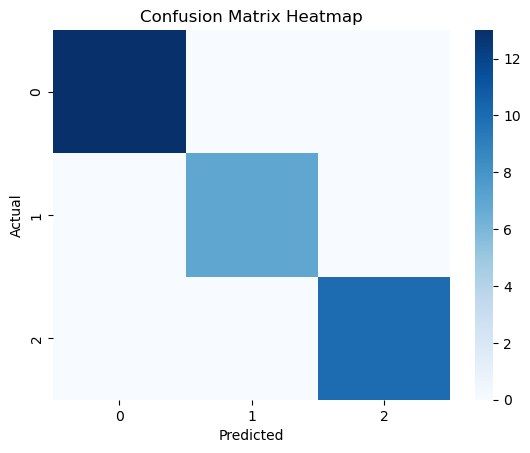

In [25]:
sns.heatmap(cm,cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()